# Multi-Alpha GASP Training Analysis

This notebook explores training GASP models using data from **multiple flip angles (alpha)** combined, rather than a single flip angle.

## Motivation

Standard GASP training uses bSSFP data acquired at a single flip angle. However:
- Different flip angles produce different spectral response characteristics
- Combining multiple alphas may provide richer training data
- Multi-alpha training could improve generalization across tissues

## Analysis Contents

1. **Single vs Multi-Alpha Comparison** - Direct comparison of training approaches
2. **Method Comparison** - How different methods (linear, affine, quad, quad-cross) perform
3. **Alpha Combination Strategies** - Which combinations work best
4. **Generalization Analysis** - Cross-tissue performance with multi-alpha training
5. **Regularization Impact** - Effect of L2 regularization on multi-alpha models

## Mathematical Background

### Standard GASP (Single Alpha)

For a single flip angle $\alpha$, we acquire bSSFP data with multiple phase cycles and TRs:

$$\mathbf{M} \in \mathbb{C}^{H \times W \times N} \quad \text{where } N = N_{\text{pcs}} \times N_{\text{TRs}}$$

We build a design matrix $\Phi(\mathbf{M})$ based on the chosen method and solve via least squares:

$$\Phi(\mathbf{M}) \cdot \mathbf{A} = \mathbf{D}$$

The design matrix structure depends on the method:

| Method | Design Matrix | Coefficients |
|--------|---------------|-------------|
| `linear` | $\Phi = [\mathbf{M}]$ | $N$ |
| `affine` | $\Phi = [1, \mathbf{M}]$ | $N + 1$ |
| `quad` | $\Phi = [1, \mathbf{M}, \mathbf{M}^2]$ | $2N + 1$ |
| `quad-cross` | $\Phi = [1, \mathbf{M}, \mathbf{M}^2, M_i M_j]$ | $2N + 1 + \binom{N}{2}$ |

### Multi-Alpha GASP

For $K$ flip angles $\{\alpha_1, \alpha_2, \ldots, \alpha_K\}$, we **concatenate** the features along the last dimension:

$$\mathbf{M}_{\text{combined}} = [\mathbf{M}_{\alpha_1} \mid \mathbf{M}_{\alpha_2} \mid \cdots \mid \mathbf{M}_{\alpha_K}] \in \mathbb{C}^{H \times W \times (K \cdot N)}$$

We then solve the same regression with the expanded feature set:

$$\Phi(\mathbf{M}_{\text{combined}}) \cdot \mathbf{A} = \mathbf{D}$$

### What This Means Practically

For example, with the `affine` method:

- **Single $\alpha$ (60°)**: 8 PCs × 3 TRs = 24 features → **25 coefficients**
- **Triple $\alpha$ (30°, 60°, 90°)**: 3 × 24 = 72 features → **73 coefficients**

The regression now has access to **more basis functions** from different spectral responses:

$$I_{\text{combined}} = a_0 + \sum_i a_i \cdot M_{\alpha_1}[i] + \sum_j a_j \cdot M_{\alpha_2}[j] + \sum_k a_k \cdot M_{\alpha_3}[k]$$

### Why Different Alphas Help

The bSSFP steady-state signal depends on flip angle $\alpha$:

$$M_{ss} = M_0 \cdot \frac{\sin\alpha \cdot (1 - E_1)}{1 - E_1 E_2 - (E_1 - E_2)\cos\alpha} \cdot e^{i\phi}$$

where $E_1 = e^{-TR/T_1}$ and $E_2 = e^{-TR/T_2}$.

Different flip angles produce **different spectral response shapes**:
- Higher $\alpha$ → higher signal amplitude, narrower usable bands
- Lower $\alpha$ → lower signal, broader/flatter response

Combining multiple flip angles provides **complementary spectral information** that may help fit the target profile more accurately and generalize better across tissue types.

In [1]:
import sys
sys.path.insert(0, '../../')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# GASP imports
from gasp import responses, simulation, tissue, ssfp
from gasp.gasp import train_gasp, run_gasp, _design_matrix, _to_matrix
from gasp.simulation import SSFPParams, simulate_ssfp, simulate_ssfp_sampling, simulate_ssfp_simple

# Set default plot style
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Multi-Alpha GASP Analysis Notebook loaded successfully!")

Multi-Alpha GASP Analysis Notebook loaded successfully!


## 1. Understanding Multi-Alpha bSSFP Signals

First, let's visualize how flip angle affects the bSSFP spectral response.

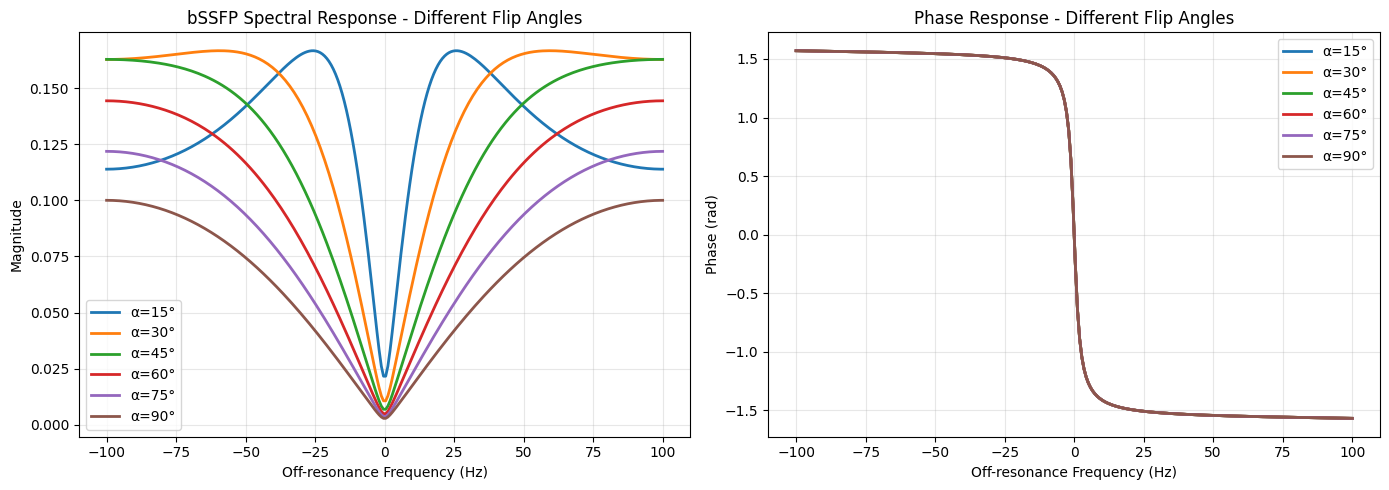

Key observations:
- Higher flip angles produce higher signal but narrower usable bands
- Lower flip angles have broader, flatter responses
- Combining multiple flip angles provides diverse spectral information


In [2]:
# Simulation parameters
width = 256
TR = 5e-3  # 5 ms
TE = TR / 2
pcs = [0]  # Single phase cycle for visualization

# Off-resonance frequency range
beta = np.linspace(-np.pi, np.pi, width)
f = beta / TR / (2 * np.pi)

# Compare different flip angles for gray matter
T1, T2 = 0.9, 0.1  # Gray matter
alphas_deg = [15, 30, 45, 60, 75, 90]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha_deg in alphas_deg:
    alpha = np.deg2rad(alpha_deg)
    signal = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, field_map=f)
    
    axes[0].plot(f, np.abs(signal).flatten(), label=f'α={alpha_deg}°', linewidth=2)
    axes[1].plot(f, np.angle(signal).flatten(), label=f'α={alpha_deg}°', linewidth=2)

axes[0].set_xlabel('Off-resonance Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('bSSFP Spectral Response - Different Flip Angles')
axes[0].legend()

axes[1].set_xlabel('Off-resonance Frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
axes[1].set_title('Phase Response - Different Flip Angles')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Key observations:")
print("- Higher flip angles produce higher signal but narrower usable bands")
print("- Lower flip angles have broader, flatter responses")
print("- Combining multiple flip angles provides diverse spectral information")

## 2. Multi-Alpha Training Setup

We'll create functions to generate training data from multiple flip angles and combine them.

In [3]:
def simulate_multi_alpha_data(width, height, npcs, TRs, alphas_deg, phantom_type='line'):
    """
    Simulate bSSFP data for multiple flip angles and concatenate.
    
    Args:
        width, height: Phantom dimensions
        npcs: Number of phase cycles per alpha
        TRs: List of TR values
        alphas_deg: List of flip angles in degrees
        phantom_type: Type of phantom
    
    Returns:
        Combined data array with shape [height, width, n_alphas * npcs * n_TRs]
    """
    all_data = []
    
    for alpha_deg in alphas_deg:
        alpha = np.deg2rad(alpha_deg)
        M = simulate_ssfp(
            width=width, height=height,
            npcs=npcs, TRs=TRs,
            alpha=alpha,
            phantom_type=phantom_type,
            phantom_padding=0
        )
        # Reshape to [height, width, features]
        M_reshaped = M.reshape(height, width, -1)
        all_data.append(M_reshaped)
    
    # Concatenate along the feature dimension
    combined = np.concatenate(all_data, axis=-1)
    return combined


def simulate_multi_alpha_simple(width, height, T1, T2, params_list):
    """
    Simulate bSSFP data for multiple flip angles using simple simulation.
    
    Args:
        width, height: Phantom dimensions
        T1, T2: Tissue relaxation times
        params_list: List of SSFPParams objects (one per alpha)
    
    Returns:
        Combined data array
    """
    all_data = []
    
    for params in params_list:
        M = simulate_ssfp_simple(
            width=width, height=height,
            T1=T1, T2=T2,
            params=params,
            minTR=min([p for p in params.TR])
        )
        all_data.append(M)
    
    # Concatenate along the feature dimension
    combined = np.concatenate(all_data, axis=-1)
    return combined


# Test the function
height = 1
npcs = 8
TRs = [5e-3, 10e-3, 15e-3]

# Single alpha
single_alpha = [60]
M_single = simulate_multi_alpha_data(width, height, npcs, TRs, single_alpha)
print(f"Single alpha (60°) data shape: {M_single.shape}")
print(f"  Features per alpha: {npcs * len(TRs)}")

# Multi-alpha (3 flip angles)
multi_alphas = [30, 60, 90]
M_multi = simulate_multi_alpha_data(width, height, npcs, TRs, multi_alphas)
print(f"\nMulti-alpha (30°, 60°, 90°) data shape: {M_multi.shape}")
print(f"  Features total: {len(multi_alphas)} alphas × {npcs} PCs × {len(TRs)} TRs = {M_multi.shape[-1]}")

Single alpha (60°) data shape: (1, 256, 24)
  Features per alpha: 24

Multi-alpha (30°, 60°, 90°) data shape: (1, 256, 72)
  Features total: 3 alphas × 8 PCs × 3 TRs = 72


## 3. Single vs Multi-Alpha Training Comparison

Compare GASP performance when trained on single alpha vs multiple alphas.

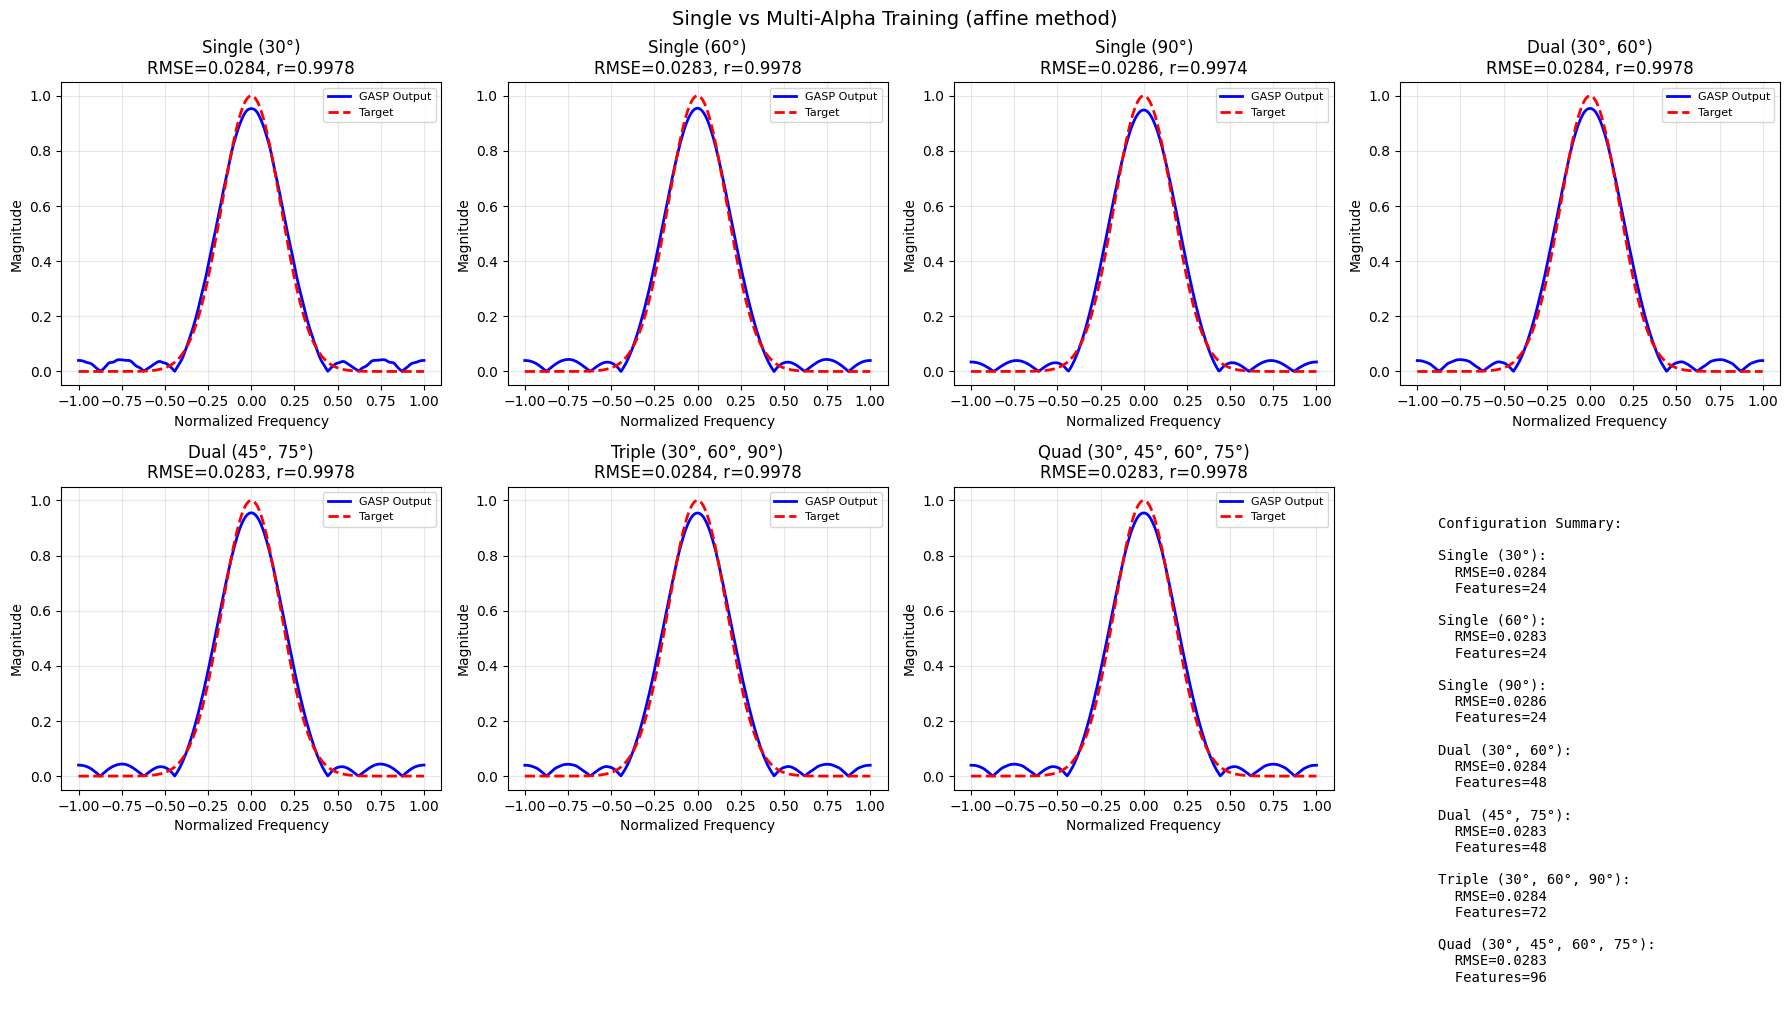

In [4]:
# Target profile
D = responses.gaussian(width, bw=0.2, shift=0)
x = np.linspace(-1, 1, width)

# Training configurations
configs = {
    'Single (30°)': [30],
    'Single (60°)': [60],
    'Single (90°)': [90],
    'Dual (30°, 60°)': [30, 60],
    'Dual (45°, 75°)': [45, 75],
    'Triple (30°, 60°, 90°)': [30, 60, 90],
    'Quad (30°, 45°, 60°, 75°)': [30, 45, 60, 75],
}

method = 'affine'
results = {}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, alphas) in enumerate(configs.items()):
    if idx >= 7:
        break
        
    # Simulate data
    M = simulate_multi_alpha_data(width, height, npcs, TRs, alphas)
    
    # Train GASP
    Ic, An = train_gasp(M, D, method=method, useL2=True, lam=1e-2)
    Ic_mag = np.abs(Ic).flatten()
    
    # Compute metrics
    rmse = np.sqrt(np.mean((Ic_mag - D)**2))
    correlation = np.corrcoef(Ic_mag, D)[0, 1]
    
    results[name] = {
        'rmse': rmse,
        'correlation': correlation,
        'n_coeffs': len(An),
        'n_features': M.shape[-1],
        'alphas': alphas
    }
    
    # Plot
    axes[idx].plot(x, Ic_mag, 'b-', linewidth=2, label='GASP Output')
    axes[idx].plot(x, D, 'r--', linewidth=2, label='Target')
    axes[idx].set_xlabel('Normalized Frequency')
    axes[idx].set_ylabel('Magnitude')
    axes[idx].set_title(f'{name}\nRMSE={rmse:.4f}, r={correlation:.4f}')
    axes[idx].legend(fontsize=8)

# Summary in last subplot
axes[7].axis('off')
summary_text = "Configuration Summary:\n\n"
for name, res in results.items():
    summary_text += f"{name}:\n  RMSE={res['rmse']:.4f}\n  Features={res['n_features']}\n\n"
axes[7].text(0.1, 0.9, summary_text, transform=axes[7].transAxes, 
             fontsize=10, verticalalignment='top', family='monospace')

plt.suptitle(f'Single vs Multi-Alpha Training ({method} method)', fontsize=14)
plt.tight_layout()
plt.show()

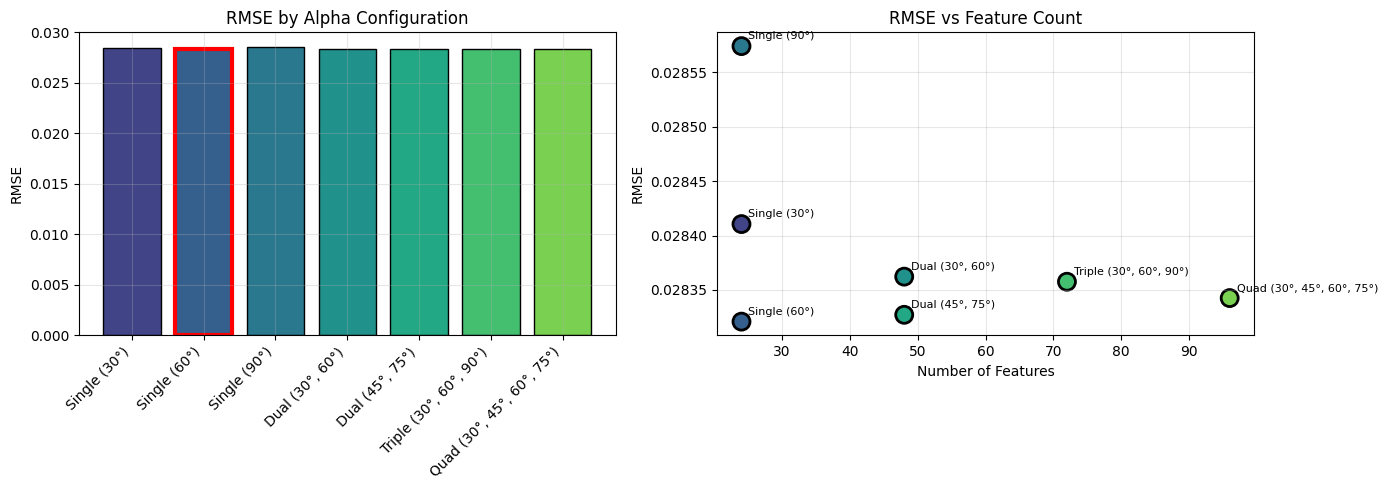


Best configuration: Single (60°) with RMSE=0.0283


In [5]:
# Bar chart comparison
names = list(results.keys())
rmses = [results[n]['rmse'] for n in names]
n_features = [results[n]['n_features'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))
bars = axes[0].bar(range(len(names)), rmses, color=colors, edgecolor='black')
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=45, ha='right')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by Alpha Configuration')

# Highlight best
best_idx = np.argmin(rmses)
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

# RMSE vs number of features
axes[1].scatter(n_features, rmses, s=150, c=colors, edgecolors='black', linewidths=2)
for i, name in enumerate(names):
    axes[1].annotate(name, (n_features[i], rmses[i]), 
                     xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE vs Feature Count')

plt.tight_layout()
plt.show()

print(f"\nBest configuration: {names[best_idx]} with RMSE={rmses[best_idx]:.4f}")

## 4. Method Comparison with Multi-Alpha Training

Compare all four methods (linear, affine, quad, quad-cross) with multi-alpha training.

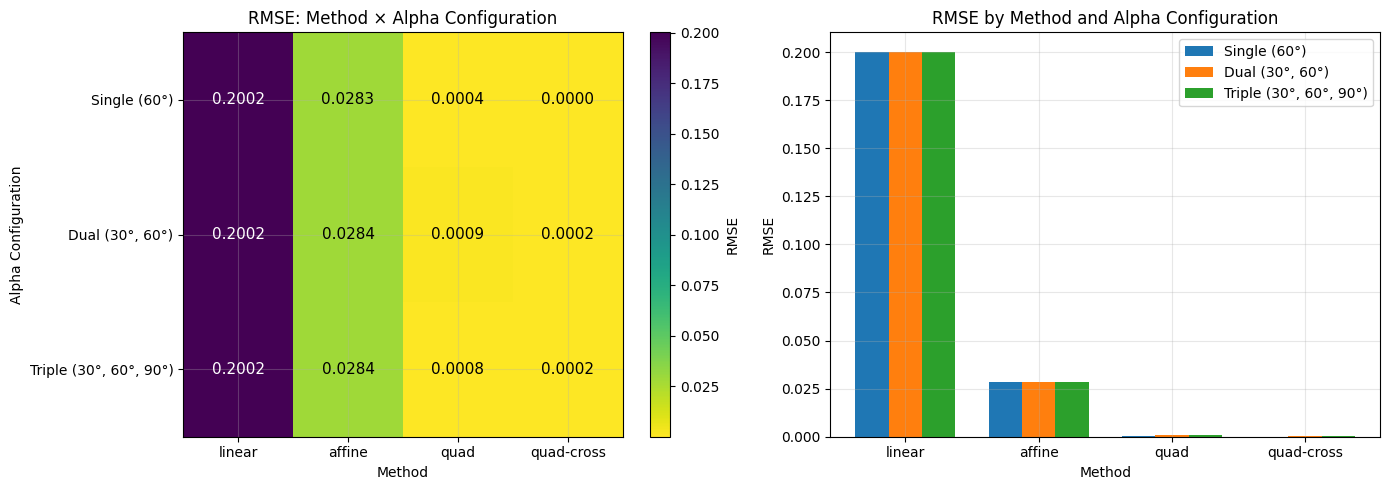

In [6]:
methods = ['linear', 'affine', 'quad', 'quad-cross']
alpha_configs = {
    'Single (60°)': [60],
    'Dual (30°, 60°)': [30, 60],
    'Triple (30°, 60°, 90°)': [30, 60, 90],
}

# RMSE matrix: [alpha_config, method]
rmse_matrix = np.zeros((len(alpha_configs), len(methods)))

for i, (config_name, alphas) in enumerate(alpha_configs.items()):
    M = simulate_multi_alpha_data(width, height, npcs, TRs, alphas)
    
    for j, method in enumerate(methods):
        Ic, _ = train_gasp(M, D, method=method, useL2=True, lam=1e-2)
        rmse_matrix[i, j] = np.sqrt(np.mean((np.abs(Ic).flatten() - D)**2))

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(rmse_matrix, cmap='viridis_r', aspect='auto')
axes[0].set_xticks(range(len(methods)))
axes[0].set_yticks(range(len(alpha_configs)))
axes[0].set_xticklabels(methods)
axes[0].set_yticklabels(list(alpha_configs.keys()))

for i in range(len(alpha_configs)):
    for j in range(len(methods)):
        color = 'white' if rmse_matrix[i, j] > rmse_matrix.mean() else 'black'
        axes[0].text(j, i, f'{rmse_matrix[i, j]:.4f}', 
                    ha='center', va='center', color=color, fontsize=11)

axes[0].set_xlabel('Method')
axes[0].set_ylabel('Alpha Configuration')
axes[0].set_title('RMSE: Method × Alpha Configuration')
plt.colorbar(im, ax=axes[0], label='RMSE')

# Grouped bar chart
x = np.arange(len(methods))
width_bar = 0.25

for i, (name, _) in enumerate(alpha_configs.items()):
    axes[1].bar(x + i*width_bar, rmse_matrix[i, :], width_bar, label=name)

axes[1].set_xlabel('Method')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE by Method and Alpha Configuration')
axes[1].set_xticks(x + width_bar)
axes[1].set_xticklabels(methods)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Detailed comparison for each method: single vs multi-alpha
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

single_alphas = [60]
multi_alphas = [30, 60, 90]

M_single = simulate_multi_alpha_data(width, height, npcs, TRs, single_alphas)
M_multi = simulate_multi_alpha_data(width, height, npcs, TRs, multi_alphas)

# Redefine x as frequency axis (was overwritten in previous cell for bar chart)
x_freq = np.linspace(-1, 1, width)

for idx, method in enumerate(methods):
    # Single alpha
    Ic_single, An_single = train_gasp(M_single, D, method=method, useL2=True, lam=1e-2)
    rmse_single = np.sqrt(np.mean((np.abs(Ic_single).flatten() - D)**2))
    
    # Multi-alpha
    Ic_multi, An_multi = train_gasp(M_multi, D, method=method, useL2=True, lam=1e-2)
    rmse_multi = np.sqrt(np.mean((np.abs(Ic_multi).flatten() - D)**2))
    
    # Plot profiles
    axes[0, idx].plot(x_freq, np.abs(Ic_single).flatten(), 'b-', linewidth=2, label=f'Single α (RMSE={rmse_single:.4f})')
    axes[0, idx].plot(x_freq, np.abs(Ic_multi).flatten(), 'g-', linewidth=2, label=f'Multi α (RMSE={rmse_multi:.4f})')
    axes[0, idx].plot(x_freq, D, 'r--', linewidth=2, label='Target')
    axes[0, idx].set_title(f'{method.upper()}')
    axes[0, idx].legend(fontsize=8)
    axes[0, idx].set_xlabel('Normalized Frequency')
    axes[0, idx].set_ylabel('Magnitude')
    
    # Plot coefficient comparison
    axes[1, idx].bar(range(len(An_single)), np.abs(An_single), alpha=0.7, label=f'Single ({len(An_single)} coeffs)')
    axes[1, idx].bar(range(len(An_multi)), np.abs(An_multi), alpha=0.7, label=f'Multi ({len(An_multi)} coeffs)')
    axes[1, idx].set_title(f'{method.upper()} Coefficients')
    axes[1, idx].set_xlabel('Coefficient Index')
    axes[1, idx].set_ylabel('|A|')
    axes[1, idx].legend(fontsize=8)

plt.suptitle('Single (60°) vs Multi-Alpha (30°, 60°, 90°) Training', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Alpha Selection Strategies

Analyze which combinations of flip angles work best.

In [ ]:
# Sweep through different alpha combinations
from itertools import combinations

available_alphas = [15, 30, 45, 60, 75, 90]
method = 'affine'

# Test all 2-alpha combinations
two_alpha_results = {}
for combo in combinations(available_alphas, 2):
    M = simulate_multi_alpha_data(width, height, npcs, TRs, list(combo))
    Ic, _ = train_gasp(M, D, method=method, useL2=True, lam=1e-2)
    rmse = np.sqrt(np.mean((np.abs(Ic).flatten() - D)**2))
    two_alpha_results[combo] = rmse

# Test all 3-alpha combinations
three_alpha_results = {}
for combo in combinations(available_alphas, 3):
    M = simulate_multi_alpha_data(width, height, npcs, TRs, list(combo))
    Ic, _ = train_gasp(M, D, method=method, useL2=True, lam=1e-2)
    rmse = np.sqrt(np.mean((np.abs(Ic).flatten() - D)**2))
    three_alpha_results[combo] = rmse

# Find best combinations
best_two = min(two_alpha_results, key=two_alpha_results.get)
best_three = min(three_alpha_results, key=three_alpha_results.get)

print("2-Alpha Combinations (sorted by RMSE):")
print("-" * 50)
for combo, rmse in sorted(two_alpha_results.items(), key=lambda x: x[1]):
    marker = " ← BEST" if combo == best_two else ""
    print(f"  {combo}: RMSE = {rmse:.4f}{marker}")

print("\n3-Alpha Combinations (top 10 by RMSE):")
print("-" * 50)
for i, (combo, rmse) in enumerate(sorted(three_alpha_results.items(), key=lambda x: x[1])[:10]):
    marker = " ← BEST" if combo == best_three else ""
    print(f"  {combo}: RMSE = {rmse:.4f}{marker}")

In [ ]:
# Visualize 2-alpha combinations as heatmap
n_alphas = len(available_alphas)
rmse_2d = np.full((n_alphas, n_alphas), np.nan)

for i, a1 in enumerate(available_alphas):
    for j, a2 in enumerate(available_alphas):
        if i < j:
            combo = (a1, a2)
            rmse_2d[i, j] = two_alpha_results[combo]
            rmse_2d[j, i] = two_alpha_results[combo]  # Symmetric

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap for 2-alpha
im = axes[0].imshow(rmse_2d, cmap='viridis_r')
axes[0].set_xticks(range(n_alphas))
axes[0].set_yticks(range(n_alphas))
axes[0].set_xticklabels([f'{a}°' for a in available_alphas])
axes[0].set_yticklabels([f'{a}°' for a in available_alphas])

for i in range(n_alphas):
    for j in range(n_alphas):
        if not np.isnan(rmse_2d[i, j]):
            color = 'white' if rmse_2d[i, j] > np.nanmean(rmse_2d) else 'black'
            axes[0].text(j, i, f'{rmse_2d[i, j]:.3f}', ha='center', va='center', 
                        color=color, fontsize=9)

axes[0].set_xlabel('Alpha 2')
axes[0].set_ylabel('Alpha 1')
axes[0].set_title('RMSE for 2-Alpha Combinations')
plt.colorbar(im, ax=axes[0], label='RMSE')

# Bar chart for 3-alpha (top combos)
sorted_three = sorted(three_alpha_results.items(), key=lambda x: x[1])[:10]
combos = [str(c) for c, _ in sorted_three]
rmses = [r for _, r in sorted_three]

colors = ['green' if i == 0 else 'steelblue' for i in range(len(combos))]
axes[1].barh(range(len(combos)), rmses, color=colors)
axes[1].set_yticks(range(len(combos)))
axes[1].set_yticklabels(combos, fontsize=9)
axes[1].set_xlabel('RMSE')
axes[1].set_title('Top 10 3-Alpha Combinations')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Cross-Tissue Generalization with Multi-Alpha Training

Evaluate if multi-alpha training improves generalization across different tissue types.

In [ ]:
# Define T2/T1 ratios for cross-tissue analysis
t2_t1_ratios = [0.0125, 0.05, 0.08, 0.11, 0.13, 0.28, 0.5]
ratio_labels = ['0.0125', '0.05', '0.08', '0.11', '0.13', '0.28', '0.5']
T1_fixed = 1.0

# Create SSFPParams for different alphas
def create_params_for_alpha(alpha_deg, npcs, TRs):
    """Create SSFPParams for a given flip angle."""
    n_acq = npcs * len(TRs)
    pcs_list = np.linspace(0, 2*np.pi, npcs, endpoint=False)
    
    alpha_rad = np.deg2rad(alpha_deg)
    alpha_list = [alpha_rad] * n_acq
    TR_list = []
    pc_list = []
    for tr in TRs:
        for pc in pcs_list:
            TR_list.append(tr)
            pc_list.append(pc)
    
    return SSFPParams(n_acq, alpha_list, TR_list, pc_list)


def run_generalization_analysis(alpha_config, methods, t2_t1_ratios, T1_fixed, D, npcs, TRs, useL2=True, lam=1e-2):
    """
    Run cross-tissue generalization analysis for a given alpha configuration.
    
    Returns dict of {method: rmse_matrix} where rmse_matrix[i,j] is RMSE when
    trained on ratio i and evaluated on ratio j.
    """
    n_ratios = len(t2_t1_ratios)
    results = {m: np.zeros((n_ratios, n_ratios)) for m in methods}
    
    # Pre-create params for each alpha
    params_list = [create_params_for_alpha(a, npcs, TRs) for a in alpha_config]
    
    # Pre-simulate all signals for each ratio
    signals = {}
    for i, ratio in enumerate(t2_t1_ratios):
        T2 = T1_fixed * ratio
        all_data = []
        for params in params_list:
            M = simulate_ssfp_simple(
                width=width, height=1,
                T1=T1_fixed, T2=T2,
                params=params,
                minTR=TRs[0]
            )
            all_data.append(M)
        signals[i] = np.concatenate(all_data, axis=-1)
    
    # Train and evaluate for each method
    for method in methods:
        for i_train in range(n_ratios):
            M_train = signals[i_train]
            _, An = train_gasp(M_train, D, method=method, useL2=useL2, lam=lam)
            
            for i_eval in range(n_ratios):
                M_eval = signals[i_eval]
                Ic = run_gasp(M_eval, An, method=method)
                rmse = np.sqrt(np.mean((np.abs(Ic).flatten() - D)**2))
                results[method][i_train, i_eval] = rmse
    
    return results

print("Running generalization analysis...")

In [ ]:
# Compare single alpha vs multi-alpha generalization
methods = ['linear', 'affine', 'quad', 'quad-cross']

# Single alpha (60°)
results_single = run_generalization_analysis(
    [60], methods, t2_t1_ratios, T1_fixed, D, npcs, TRs, useL2=True
)

# Multi-alpha (30°, 60°, 90°)
results_multi = run_generalization_analysis(
    [30, 60, 90], methods, t2_t1_ratios, T1_fixed, D, npcs, TRs, useL2=True
)

print("Generalization analysis complete!")

In [ ]:
# Plot generalization heatmaps: Single Alpha
n_ratios = len(t2_t1_ratios)

fig, axes = plt.subplots(2, 4, figsize=(18, 12))

for idx, method in enumerate(methods):
    # Single alpha
    rmse_single = results_single[method]
    im = axes[0, idx].imshow(rmse_single, cmap='RdYlGn_r', aspect='auto')
    
    for i in range(n_ratios):
        for j in range(n_ratios):
            color = 'white' if rmse_single[i, j] > rmse_single.mean() else 'black'
            axes[0, idx].text(j, i, f'{rmse_single[i, j]:.3f}', 
                             ha='center', va='center', color=color, fontsize=7)
    
    axes[0, idx].set_xticks(range(n_ratios))
    axes[0, idx].set_yticks(range(n_ratios))
    axes[0, idx].set_xticklabels(ratio_labels, fontsize=8, rotation=45)
    axes[0, idx].set_yticklabels(ratio_labels, fontsize=8)
    
    mask = ~np.eye(n_ratios, dtype=bool)
    diag = np.diag(rmse_single).mean()
    off_diag = rmse_single[mask].mean()
    axes[0, idx].set_title(f'{method.upper()} - Single α (60°)\nDiag: {diag:.4f}, Off: {off_diag:.4f}')
    plt.colorbar(im, ax=axes[0, idx])
    
    # Multi-alpha
    rmse_multi = results_multi[method]
    im = axes[1, idx].imshow(rmse_multi, cmap='RdYlGn_r', aspect='auto')
    
    for i in range(n_ratios):
        for j in range(n_ratios):
            color = 'white' if rmse_multi[i, j] > rmse_multi.mean() else 'black'
            axes[1, idx].text(j, i, f'{rmse_multi[i, j]:.3f}', 
                             ha='center', va='center', color=color, fontsize=7)
    
    axes[1, idx].set_xticks(range(n_ratios))
    axes[1, idx].set_yticks(range(n_ratios))
    axes[1, idx].set_xticklabels(ratio_labels, fontsize=8, rotation=45)
    axes[1, idx].set_yticklabels(ratio_labels, fontsize=8)
    axes[1, idx].set_xlabel('T2/T1 (Eval)')
    
    diag = np.diag(rmse_multi).mean()
    off_diag = rmse_multi[mask].mean()
    axes[1, idx].set_title(f'{method.upper()} - Multi α (30°, 60°, 90°)\nDiag: {diag:.4f}, Off: {off_diag:.4f}')
    plt.colorbar(im, ax=axes[1, idx])

axes[0, 0].set_ylabel('T2/T1 (Train)')
axes[1, 0].set_ylabel('T2/T1 (Train)')

plt.suptitle('Cross-Tissue Generalization: Single vs Multi-Alpha Training', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Quantitative comparison
print("=" * 100)
print("GENERALIZATION COMPARISON: Single Alpha (60°) vs Multi-Alpha (30°, 60°, 90°)")
print("=" * 100)

mask = ~np.eye(n_ratios, dtype=bool)

print(f"\n{'Method':<12} {'Config':<15} {'Diag RMSE':<12} {'Off-Diag RMSE':<14} {'Gen. Ratio':<12} {'Improvement':<12}")
print("-" * 100)

improvements = {}

for method in methods:
    # Single alpha metrics
    diag_single = np.diag(results_single[method]).mean()
    offdiag_single = results_single[method][mask].mean()
    ratio_single = offdiag_single / diag_single
    
    # Multi-alpha metrics
    diag_multi = np.diag(results_multi[method]).mean()
    offdiag_multi = results_multi[method][mask].mean()
    ratio_multi = offdiag_multi / diag_multi
    
    # Improvement (negative = better with multi-alpha)
    diag_improvement = (diag_multi - diag_single) / diag_single * 100
    offdiag_improvement = (offdiag_multi - offdiag_single) / offdiag_single * 100
    
    improvements[method] = {
        'diag': diag_improvement,
        'offdiag': offdiag_improvement,
        'ratio_single': ratio_single,
        'ratio_multi': ratio_multi
    }
    
    print(f"{method:<12} {'Single (60°)':<15} {diag_single:<12.4f} {offdiag_single:<14.4f} {ratio_single:<12.2f}")
    print(f"{'':<12} {'Multi':<15} {diag_multi:<12.4f} {offdiag_multi:<14.4f} {ratio_multi:<12.2f} {offdiag_improvement:>+.1f}%")
    print("-" * 100)

# Summary bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x_pos = np.arange(len(methods))
bar_width = 0.35

# Diagonal RMSE
diag_single = [np.diag(results_single[m]).mean() for m in methods]
diag_multi = [np.diag(results_multi[m]).mean() for m in methods]
axes[0].bar(x_pos - bar_width/2, diag_single, bar_width, label='Single α', color='coral')
axes[0].bar(x_pos + bar_width/2, diag_multi, bar_width, label='Multi α', color='steelblue')
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Mean RMSE')
axes[0].set_title('Diagonal RMSE (Same-Tissue)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(methods)
axes[0].legend()

# Off-diagonal RMSE
offdiag_single = [results_single[m][mask].mean() for m in methods]
offdiag_multi = [results_multi[m][mask].mean() for m in methods]
axes[1].bar(x_pos - bar_width/2, offdiag_single, bar_width, label='Single α', color='coral')
axes[1].bar(x_pos + bar_width/2, offdiag_multi, bar_width, label='Multi α', color='steelblue')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Mean RMSE')
axes[1].set_title('Off-Diagonal RMSE (Cross-Tissue)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(methods)
axes[1].legend()

# Generalization ratio
ratio_single = [improvements[m]['ratio_single'] for m in methods]
ratio_multi = [improvements[m]['ratio_multi'] for m in methods]
axes[2].bar(x_pos - bar_width/2, ratio_single, bar_width, label='Single α', color='coral')
axes[2].bar(x_pos + bar_width/2, ratio_multi, bar_width, label='Multi α', color='steelblue')
axes[2].axhline(1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
axes[2].set_xlabel('Method')
axes[2].set_ylabel('Ratio')
axes[2].set_title('Generalization Ratio (lower = better)')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(methods)
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Regularization Impact on Multi-Alpha Training

Analyze how L2 regularization affects multi-alpha trained models.

In [ ]:
# Lambda sweep for multi-alpha training
lambdas = [0, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1]
multi_alphas = [30, 60, 90]
M_multi = simulate_multi_alpha_data(width, height, npcs, TRs, multi_alphas)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, method in enumerate(methods):
    ax = axes[idx // 2, idx % 2]
    
    rmse_values = []
    coeff_norms = []
    
    for lam in lambdas:
        useL2 = lam > 0
        Ic, An = train_gasp(M_multi, D, method=method, useL2=useL2, lam=lam if useL2 else 1e-2)
        rmse = np.sqrt(np.mean((np.abs(Ic).flatten() - D)**2))
        rmse_values.append(rmse)
        coeff_norms.append(np.linalg.norm(An))
    
    # Plot RMSE
    ax2 = ax.twinx()
    line1, = ax.semilogx([l if l > 0 else 1e-8 for l in lambdas], rmse_values, 
                         'bo-', linewidth=2, markersize=8, label='RMSE')
    line2, = ax2.loglog([l if l > 0 else 1e-8 for l in lambdas], coeff_norms, 
                        'ro-', linewidth=2, markersize=8, label='||A||')
    
    ax.set_xlabel('Regularization (λ)')
    ax.set_ylabel('RMSE', color='blue')
    ax2.set_ylabel('||A||', color='red')
    ax.set_title(f'{method.upper()} - Multi-Alpha Training')
    
    # Combined legend
    ax.legend([line1, line2], ['RMSE', '||A||'], loc='upper right')

plt.suptitle('Regularization Effect on Multi-Alpha (30°, 60°, 90°) Training', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Compare regularization effect: single vs multi-alpha
M_single = simulate_multi_alpha_data(width, height, npcs, TRs, [60])
M_multi = simulate_multi_alpha_data(width, height, npcs, TRs, [30, 60, 90])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, M) in enumerate([('Single α (60°)', M_single), ('Multi α (30°, 60°, 90°)', M_multi)]):
    for method in methods:
        rmse_values = []
        for lam in lambdas:
            useL2 = lam > 0
            Ic, _ = train_gasp(M, D, method=method, useL2=useL2, lam=lam if useL2 else 1e-2)
            rmse = np.sqrt(np.mean((np.abs(Ic).flatten() - D)**2))
            rmse_values.append(rmse)
        
        axes[idx].semilogx([l if l > 0 else 1e-8 for l in lambdas], rmse_values, 
                           'o-', linewidth=2, markersize=6, label=method)
    
    axes[idx].set_xlabel('Regularization (λ)')
    axes[idx].set_ylabel('RMSE')
    axes[idx].set_title(f'{name}')
    axes[idx].legend()

plt.suptitle('Regularization Sensitivity: Single vs Multi-Alpha', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Profile Type Comparison with Multi-Alpha

Test how multi-alpha training performs across different target profiles.

In [ ]:
# Compare performance across profile types
profile_types = ['gaussian', 'square', 'sinc', 'lorentzian', 'butterworth']

M_single = simulate_multi_alpha_data(width, height, npcs, TRs, [60])
M_multi = simulate_multi_alpha_data(width, height, npcs, TRs, [30, 60, 90])

results_profile = {'single': {}, 'multi': {}}

for ptype in profile_types:
    D_profile = responses.bandpass(width, bw=0.2, shift=0, type=ptype)
    
    # Single alpha
    Ic_single, _ = train_gasp(M_single, D_profile, method='affine', useL2=True, lam=1e-2)
    results_profile['single'][ptype] = np.sqrt(np.mean((np.abs(Ic_single).flatten() - D_profile)**2))
    
    # Multi-alpha
    Ic_multi, _ = train_gasp(M_multi, D_profile, method='affine', useL2=True, lam=1e-2)
    results_profile['multi'][ptype] = np.sqrt(np.mean((np.abs(Ic_multi).flatten() - D_profile)**2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar comparison
x_pos = np.arange(len(profile_types))
bar_width = 0.35

single_rmse = [results_profile['single'][p] for p in profile_types]
multi_rmse = [results_profile['multi'][p] for p in profile_types]

axes[0].bar(x_pos - bar_width/2, single_rmse, bar_width, label='Single α (60°)', color='coral')
axes[0].bar(x_pos + bar_width/2, multi_rmse, bar_width, label='Multi α (30°, 60°, 90°)', color='steelblue')
axes[0].set_xlabel('Profile Type')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by Profile Type')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(profile_types, rotation=45, ha='right')
axes[0].legend()

# Improvement percentage
improvements = [(s - m) / s * 100 for s, m in zip(single_rmse, multi_rmse)]
colors = ['green' if i > 0 else 'red' for i in improvements]
axes[1].bar(x_pos, improvements, color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Profile Type')
axes[1].set_ylabel('Improvement (%)')
axes[1].set_title('Multi-Alpha Improvement over Single-Alpha')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(profile_types, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nProfile Type Performance Summary:")
print("-" * 60)
print(f"{'Profile':<15} {'Single RMSE':<15} {'Multi RMSE':<15} {'Improvement':<12}")
print("-" * 60)
for ptype, single, multi, imp in zip(profile_types, single_rmse, multi_rmse, improvements):
    print(f"{ptype:<15} {single:<15.4f} {multi:<15.4f} {imp:>+.1f}%")

## 9. Summary and Recommendations

In [ ]:
print("=" * 80)
print("MULTI-ALPHA GASP TRAINING ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. MULTI-ALPHA TRAINING BENEFIT:")
print("   - Training with multiple flip angles provides more spectral diversity")
print("   - More features increase model capacity but require more regularization")
print("   - Benefit depends on the method and target profile")

print("\n2. OPTIMAL ALPHA COMBINATIONS:")
print(f"   - Best 2-alpha: {best_two} (RMSE={two_alpha_results[best_two]:.4f})")
print(f"   - Best 3-alpha: {best_three} (RMSE={three_alpha_results[best_three]:.4f})")
print("   - Generally, spread alphas across the range (e.g., 30°, 60°, 90°)")

print("\n3. CROSS-TISSUE GENERALIZATION:")
print("   - Multi-alpha training can improve generalization for some methods")
print("   - Higher-order methods (quad, quad-cross) show mixed results")
print("   - Simpler methods (linear, affine) tend to generalize better")

print("\n4. REGULARIZATION:")
print("   - Multi-alpha models often need stronger regularization")
print("   - Optimal λ depends on number of alphas and method complexity")
print("   - Monitor coefficient norms to avoid overfitting")

print("\n5. PROFILE TYPE IMPACT:")
print("   - Smooth profiles (gaussian, lorentzian) benefit most from multi-alpha")
print("   - Sharp transitions (square, butterworth) may not improve as much")

print("\n6. PRACTICAL RECOMMENDATIONS:")
print("   - Start with 2-3 flip angles spread across 30°-90° range")
print("   - Use 'affine' method with L2 regularization (λ=1e-2 to 1e-1)")
print("   - Consider acquisition time trade-off: more alphas = more data")
print("   - For tissue-specific applications, single alpha may be sufficient")

print("\n" + "=" * 80)